In [1]:
import pandas as pd
import numpy as np
import math

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

/home/tyumen/saiga_8b/saiga_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
texts_df = pd.read_csv('ru_cefr_short.csv')  
features_df = pd.read_csv('ru_cefr_short_linguistic_features.csv')  


if 'text' in features_df.columns:
    features_df = features_df.drop(columns=['text'])
if 'level_number' in features_df.columns:
    features_df = features_df.drop(columns=['level_number'])

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_name = "ai-forever/ruRoberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name).to(device)

print(f"Модель инициализирована")

Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ruRoberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [4]:
def get_bert_embeddings(texts, batch_size=16):
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            model_output = bert_model(**encoded)

        batch_embeddings = model_output.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

texts = texts_df['fragment'].fillna('').astype(str).tolist()
bert_embeddings = get_bert_embeddings(texts)
print(f"Размер BERT эмбеддингов: {bert_embeddings.shape}")

Размер BERT эмбеддингов: (7322, 1024)


In [5]:
X_numerical = features_df.values

X_combined = np.hstack([X_numerical, bert_embeddings])
print(f"Объединенные фичи: {X_combined.shape}")
print(f"Числовые фичи: {X_numerical.shape[1]}, BERT эмбеддинги: {bert_embeddings.shape[1]}")

Объединенные фичи: (7322, 1145)
Числовые фичи: 121, BERT эмбеддинги: 1024


# Классификация

In [6]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Classifier', CatBoostClassifier(random_state=42, verbose=False)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Naive Bayes', GaussianNB()),
    ('XGBoost', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1, n_estimators=100))
]

In [7]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

## Классификация. С1 и С2 раздельно

In [8]:
y = texts_df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [9]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [10]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded)

        y_pred_original = le.inverse_transform(model.predict(X_test_scaled))

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: XGBoost
Обработка: LightGBM


In [11]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,7,XGBoost,0.626621,0.626621,0.543512,0.619646,0.476451
1,3,CatBoost Classifier,0.617065,0.617065,0.531867,0.610750,0.489420
2,4,SVM,0.617065,0.617065,0.531276,0.609218,0.491468
3,8,LightGBM,0.610922,0.610922,0.532362,0.604743,0.496928
4,0,Logistic Regression,0.590444,0.590444,0.556718,0.590007,0.537201
5,5,K-Nearest Neighbors,0.557679,0.557679,0.517625,0.551392,0.653242
6,2,Random Forest,0.539932,0.539932,0.441692,0.526239,0.600000
7,1,Decision Tree,0.406143,0.406143,0.352798,0.406713,0.857338
8,6,Naive Bayes,0.180887,0.180887,0.139089,0.137906,1.737884


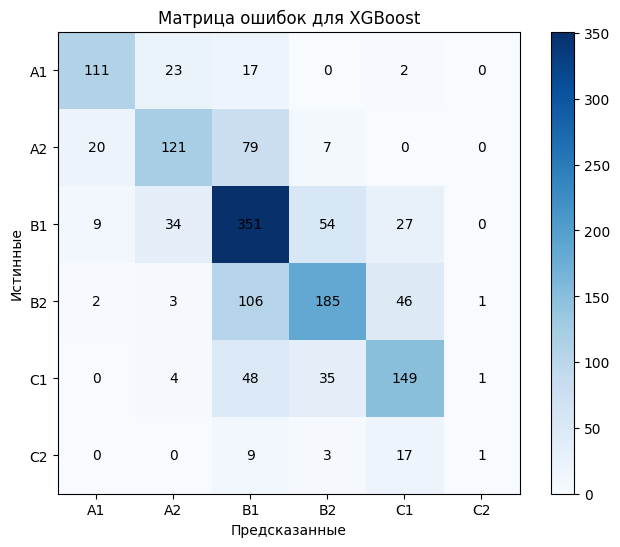

In [12]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Классификация. С1 и С2 вместе

In [13]:
y = texts_df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [14]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [15]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded)

        y_pred_original = le.inverse_transform(model.predict(X_test_scaled))

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: XGBoost
Обработка: LightGBM


In [16]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,SVM,0.634130,0.634130,0.637049,0.632116,0.469625
1,3,CatBoost Classifier,0.631399,0.631399,0.634871,0.629550,0.458703
2,8,LightGBM,0.616382,0.616382,0.629848,0.616407,0.480546
3,7,XGBoost,0.615017,0.615017,0.623518,0.613812,0.481911
4,0,Logistic Regression,0.584983,0.584983,0.593609,0.585033,0.537201
5,5,K-Nearest Neighbors,0.567918,0.567918,0.567797,0.564402,0.621160
6,2,Random Forest,0.566553,0.566553,0.555008,0.559008,0.553584
7,1,Decision Tree,0.417065,0.417065,0.422022,0.417596,0.810239
8,6,Naive Bayes,0.212969,0.212969,0.178461,0.168681,1.617065


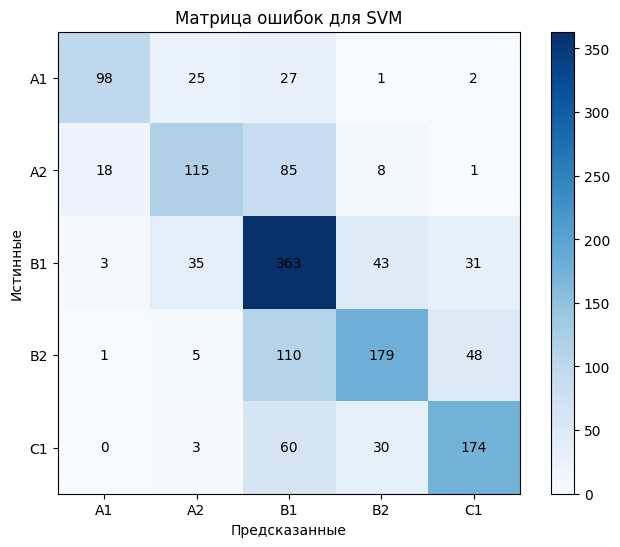

In [17]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

# Регрессия

In [18]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    # ('Random Forest', RandomForestRegressor(random_state=42, max_depth=5)),
    # ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Regressor', CatBoostRegressor(random_state=42, verbose=False)),
    ('SVM', SVR()),
    ('K-Nearest Neighbors', KNeighborsRegressor()),
    # ('Naive Bayes', GaussianNB()),
    ('XGBoost', XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMRegressor(random_state=42, verbose=-1, n_estimators=100))
]

## Регрессия. С1 и С2 раздельно

In [19]:
y = texts_df['textbook-assigned cefr level'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [20]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [21]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 6).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [22]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'math')

        y_pred = model.predict(X_test_scaled)
        y_pred = [round(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [23]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,SVM,0.533788,0.533788,0.437871,0.523683,0.531058
1,2,CatBoost Regressor,0.527645,0.527645,0.442967,0.522383,0.525597
2,6,LightGBM,0.516041,0.516041,0.436845,0.511660,0.541297
3,5,XGBoost,0.503754,0.503754,0.426932,0.500412,0.567918
4,4,K-Nearest Neighbors,0.494881,0.494881,0.435635,0.488477,0.609556
5,0,Linear Regression,0.473720,0.473720,0.414164,0.474262,0.599317
6,1,Decision Tree,0.400000,0.400000,0.367436,0.399702,0.839590


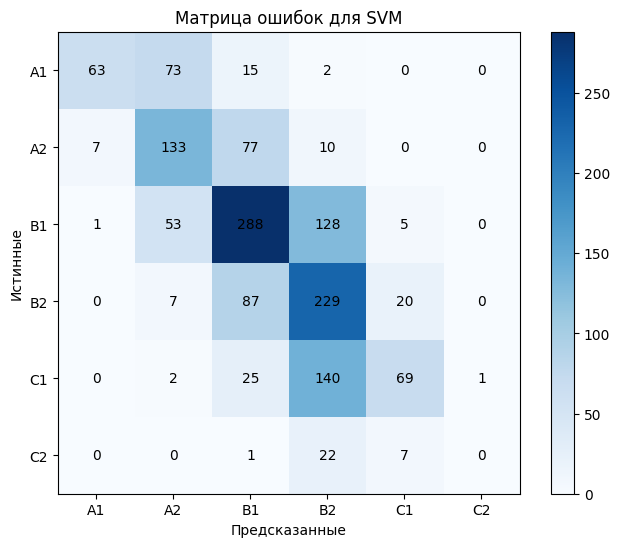

In [24]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [25]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'ceil')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.ceil(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [26]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,K-Nearest Neighbors,0.444369,0.444369,0.382779,0.436274,0.652560
1,1,Decision Tree,0.400000,0.400000,0.367436,0.399702,0.839590
2,3,SVM,0.402730,0.402730,0.314964,0.383210,0.688055
3,2,CatBoost Regressor,0.401365,0.401365,0.323718,0.382858,0.693515
4,5,XGBoost,0.395222,0.395222,0.316735,0.382434,0.733788
5,0,Linear Regression,0.376109,0.376109,0.318132,0.376888,0.743345
6,6,LightGBM,0.378157,0.378157,0.309104,0.362130,0.727645


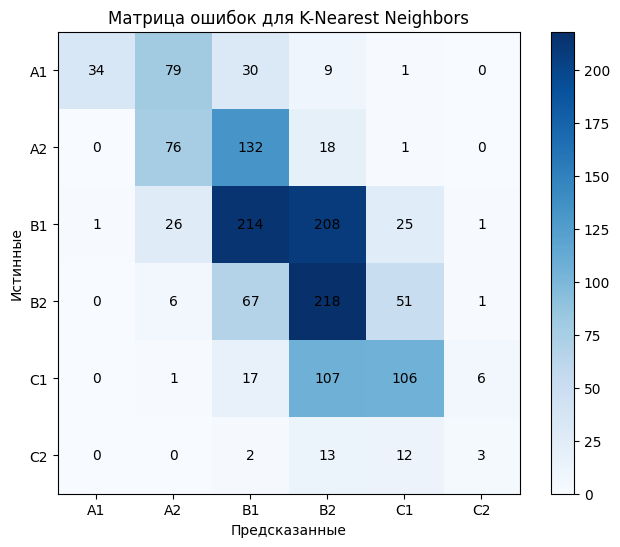

In [27]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [28]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'floor')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.floor(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 5).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [29]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,6,LightGBM,0.450512,0.450512,0.360336,0.420668,0.664846
1,0,Linear Regression,0.431399,0.431399,0.370916,0.415864,0.701024
2,2,CatBoost Regressor,0.445051,0.445051,0.355757,0.413989,0.657338
3,3,SVM,0.437543,0.437543,0.351554,0.403299,0.673038
4,1,Decision Tree,0.400000,0.400000,0.367436,0.399702,0.839590
5,5,XGBoost,0.406826,0.406826,0.334141,0.383898,0.720819
6,4,K-Nearest Neighbors,0.411604,0.411604,0.335313,0.382040,0.745392


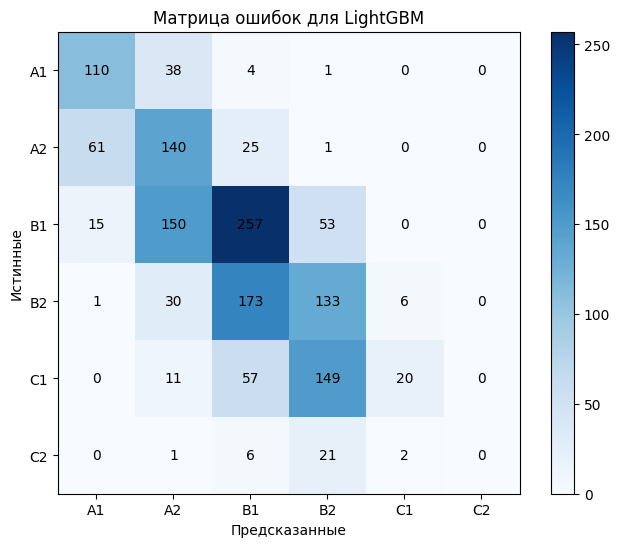

In [30]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

## Регрессия. С1 и С2 вместе

In [31]:
y = texts_df['textbook-assigned cefr level'].replace(6, 5).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [32]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

In [33]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test, round_type):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if round_type == 'math':
        y_pred = [round(i) for i in y_pred]
    elif round_type == 'ceil':
        y_pred = [math.ceil(i) for i in y_pred] 
    elif round_type == 'floor':
        y_pred = [math.floor(i) for i in y_pred] 

    y_pred = np.clip(y_pred, 1, 5).tolist()

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

### Математическое округление

In [34]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'math')

        y_pred = model.predict(X_test_scaled)
        y_pred = [round(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'math')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [35]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,3,SVM,0.536519,0.536519,0.525329,0.530669,0.515358
1,6,LightGBM,0.531741,0.531741,0.534606,0.530179,0.513311
2,5,XGBoost,0.526962,0.526962,0.531612,0.526080,0.532423
3,2,CatBoost Regressor,0.522867,0.522867,0.518458,0.519494,0.512628
4,0,Linear Regression,0.504437,0.504437,0.501677,0.505792,0.549488
5,4,K-Nearest Neighbors,0.493515,0.493515,0.490309,0.487334,0.589078
6,1,Decision Tree,0.418430,0.418430,0.437117,0.418213,0.779522


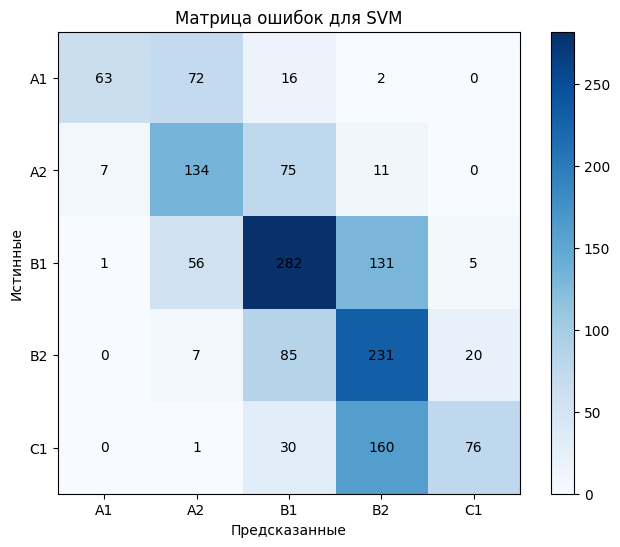

In [36]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вверх

In [37]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'ceil')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.ceil(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'ceil')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [38]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,4,K-Nearest Neighbors,0.455290,0.455290,0.439629,0.450493,0.632082
1,1,Decision Tree,0.418430,0.418430,0.437117,0.418213,0.779522
2,0,Linear Regression,0.425256,0.425256,0.393936,0.412611,0.668259
3,2,CatBoost Regressor,0.425256,0.425256,0.391138,0.408133,0.657338
4,3,SVM,0.427986,0.427986,0.386210,0.407659,0.653242
5,5,XGBoost,0.409556,0.409556,0.383098,0.394465,0.697611
6,6,LightGBM,0.412287,0.412287,0.373422,0.392503,0.669625


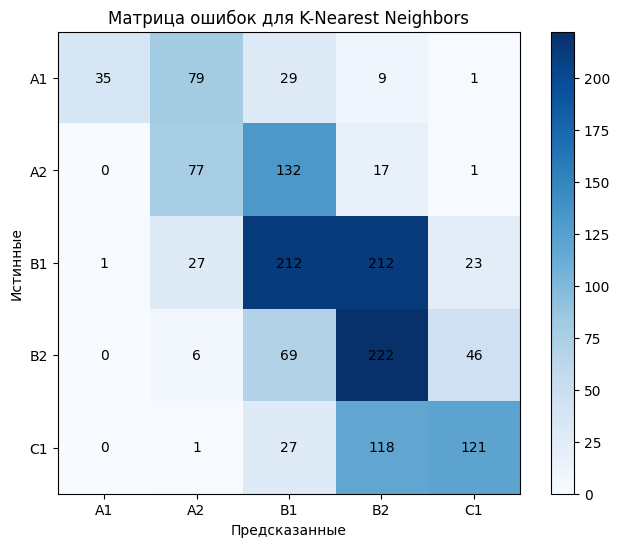

In [39]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()

### Округление вниз

In [40]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    if model_name == 'XGBoost':
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train_encoded, y_test_encoded, 'floor')

        y_pred = model.predict(X_test_scaled)
        y_pred = [math.floor(i) for i in y_pred]
        y_pred = np.clip(y_pred, 0, 4).tolist()
        y_pred_original = le.inverse_transform(y_pred)

        result['accuracy'] = accuracy_score(y_test_orig, y_pred_original)
        result['f1_micro'] = f1_score(y_test_orig, y_pred_original, average='micro', zero_division=0)
        result['f1_macro'] = f1_score(y_test_orig, y_pred_original, average='macro', zero_division=0)
        result['f1_weighted'] = f1_score(y_test_orig, y_pred_original, average='weighted', zero_division=0)
        result['mae'] = mean_absolute_error(y_test_orig, y_pred_original)
        result['classification_report'] = classification_report(y_test_orig, y_pred_original, zero_division=0)
        result['confusion_matrix'] = confusion_matrix(y_test_orig, y_pred_original)
    else:
        result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test, 'floor')

    results.append(result)

Обработка: Linear Regression
Обработка: Decision Tree
Обработка: CatBoost Regressor
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: XGBoost
Обработка: LightGBM


In [41]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,0,Linear Regression,0.439590,0.439590,0.450152,0.427375,0.677816
1,1,Decision Tree,0.418430,0.418430,0.437117,0.418213,0.779522
2,6,LightGBM,0.445051,0.445051,0.413694,0.403473,0.653242
3,3,SVM,0.438908,0.438908,0.418976,0.403166,0.654608
4,2,CatBoost Regressor,0.440956,0.440956,0.412902,0.402017,0.653242
5,5,XGBoost,0.432082,0.432082,0.411423,0.401930,0.677133
6,4,K-Nearest Neighbors,0.410239,0.410239,0.392157,0.376165,0.733788


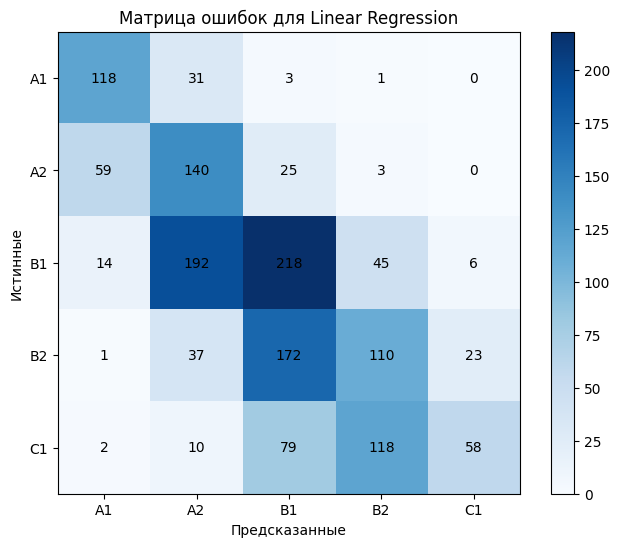

In [42]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()